# CASE STUDY 2 — SÀNG LỌC SỚM NGUY CƠ ĐÁI THÁO ĐƯỜNG (PIMA INDIANS DIABETES)

**Môn:** Thực hành Trực quan hóa Dữ liệu — Bài 1: Trực quan hóa dữ liệu liên quan tới y tế


**Tình huống:** Một phòng khám nội tiết muốn xây dựng công cụ sàng lọc sớm nguy cơ đái tháo đường cho bệnh nhân nữ dựa trên các chỉ số khám sức khỏe định kỳ. Nhiệm vụ: phân tích dữ liệu lịch sử để tìm các chỉ số liên hệ mạnh nhất với nguy cơ mắc bệnh.

**Nội dung notebook**
1. Yêu cầu 1 — Tải và khám phá dữ liệu
2. Yêu cầu 2 — Tiền xử lý và làm sạch (giá trị 0 không hợp lệ, trùng lặp)
3. Yêu cầu 3 — Phân tích dữ liệu thăm dò (EDA)
4. Yêu cầu 4 — Trực quan hóa bằng đủ 7 loại biểu đồ
5. Yêu cầu 5 — Mô hình Hồi quy Logistic
6. Kết luận (3 chỉ số mạnh nhất + 2 đề xuất sàng lọc)

## 0. Import thư viện và cấu hình biểu đồ

- `pandas`, `numpy`: xử lý dữ liệu; `matplotlib`, `seaborn`: vẽ biểu đồ; `scikit-learn`: mô hình dự đoán.
- Mọi hình được lưu vào thư mục `figures/` (dpi=150) để dùng lại cho báo cáo Word và slide.

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)

# Style chung cho toàn bộ biểu đồ
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"   # hiển thị được tiếng Việt có dấu

# Màu cố định cho 2 nhóm Outcome (dùng thống nhất ở mọi biểu đồ)
COLOR_NO = "#2a9d8f"    # Không mắc bệnh (Outcome = 0)
COLOR_YES = "#e76f51"   # Mắc bệnh (Outcome = 1)
OUTCOME_PALETTE = {0: COLOR_NO, 1: COLOR_YES}
OUTCOME_LABELS = {0: "Không mắc (0)", 1: "Mắc bệnh (1)"}

# Thư mục lưu hình
os.makedirs("figures", exist_ok=True)

def save_fig(name):
    # Lưu hình hiện tại vào figures/ với độ phân giải 150 dpi
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

pd.set_option("display.float_format", "{:.3f}".format)   # hiển thị 3 chữ số thập phân
print("Đã nạp thư viện xong.")

Đã nạp thư viện xong.


## 1. Yêu cầu 1 — Tải và khám phá dữ liệu

**Nguồn dữ liệu:** "Pima Indians Diabetes Database" — https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database (gốc: National Institute of Diabetes and Digestive and Kidney Diseases).

Đặt file `diabetes.csv` cùng thư mục với notebook. Nếu không có file (không truy cập được Kaggle), code tự chuyển sang **dữ liệu mô phỏng** theo mục 2* của đề để notebook vẫn chạy được.

In [28]:
def generate_synthetic_diabetes_data(n=768, seed=42):
    # Hàm tạo dữ liệu mô phỏng — chép từ mục 2* của đề, chỉ dùng khi thiếu file diabetes.csv
    rng = np.random.default_rng(seed)
    outcome = rng.binomial(1, 0.349, n)
    pregnancies = np.where(outcome == 1, rng.poisson(4.9, n), rng.poisson(3.3, n))
    pregnancies = np.clip(pregnancies, 0, 17)
    glucose = np.where(outcome == 1, rng.normal(141, 32, n), rng.normal(110, 25, n))
    glucose = np.clip(glucose, 44, 199).round().astype(int)
    blood_pressure = np.clip(rng.normal(72, 12.4, n), 24, 122).round().astype(int)
    skin_thickness = np.clip(rng.normal(20.5, 16, n), 0, 99).round().astype(int)
    insulin = np.where(outcome == 1, rng.gamma(2.0, 90, n), rng.gamma(1.5, 70, n))
    insulin = np.clip(insulin, 0, 846).round().astype(int)
    bmi = np.where(outcome == 1, rng.normal(35.1, 6.6, n), rng.normal(30.3, 7.7, n))
    bmi = np.clip(bmi, 0, 67.1).round(1)
    dpf = np.clip(rng.gamma(2.0, 0.22, n), 0.078, 2.42).round(3)
    age = np.clip(rng.gamma(3.0, 10.5, n) + 21, 21, 81).round().astype(int)

    def inject_zero(arr, rate):
        arr = arr.copy()
        idx = rng.choice(len(arr), size=int(len(arr) * rate), replace=False)
        arr[idx] = 0
        return arr

    glucose = inject_zero(glucose, 0.007)
    blood_pressure = inject_zero(blood_pressure, 0.045)
    skin_thickness = inject_zero(skin_thickness, 0.295)
    insulin = inject_zero(insulin, 0.487)
    bmi = inject_zero(bmi, 0.014)
    return pd.DataFrame({
        "Pregnancies": pregnancies, "Glucose": glucose,
        "BloodPressure": blood_pressure, "SkinThickness": skin_thickness,
        "Insulin": insulin, "BMI": bmi,
        "DiabetesPedigreeFunction": dpf, "Age": age, "Outcome": outcome,
    })

file_path = "diabetes.csv"
if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path)
    print("Đã đọc dữ liệu THẬT từ", file_path)
else:
    df_raw = generate_synthetic_diabetes_data()
    print("Không tìm thấy diabetes.csv -> dùng dữ liệu MÔ PHỎNG (mục 2* của đề)")

print("Kích thước dữ liệu (dòng, cột):", df_raw.shape)

Đã đọc dữ liệu THẬT từ diabetes.csv
Kích thước dữ liệu (dòng, cột): (768, 9)


In [29]:
# Kiểu dữ liệu và số giá trị non-null của từng cột
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
# 5 dòng đầu
df_raw.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [31]:
# 5 dòng cuối
df_raw.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.900,0.171,63,0
764,2,122,70,27,0,36.800,0.340,27,0
765,5,121,72,23,112,26.200,0.245,30,0
766,1,126,60,0,0,30.100,0.349,47,1
767,1,93,70,31,0,30.400,0.315,23,0


In [32]:
# Thống kê mô tả dữ liệu GỐC — chú ý cột min
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


**Nhận xét Yêu cầu 1**

- Dữ liệu gồm **768 dòng × 9 cột**, tất cả là kiểu số (`int64`/`float64`): 8 biến đầu vào + 1 biến mục tiêu `Outcome`.
- `info()` báo **không có ô NULL nào** — nhưng đây là "bẫy": ở `describe()`, **min của Glucose, BloodPressure, SkinThickness, Insulin, BMI đều bằng 0**, điều không thể xảy ra ở người sống. Giá trị thiếu đã bị mã hóa thành 0 → phải xử lý ở Yêu cầu 2.
- `Pregnancies = 0` là hợp lệ (chưa từng mang thai) nên **không** xử lý cột này.

## 2. Yêu cầu 2 — Tiền xử lý và làm sạch

### 2.1. Phát hiện giá trị 0 không hợp lệ

In [33]:
# 5 cột mà giá trị 0 là vô lý về sinh học
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_table = pd.DataFrame({
    "Số giá trị 0": (df_raw[zero_cols] == 0).sum(),
    "Tỷ lệ (%)": ((df_raw[zero_cols] == 0).mean() * 100).round(1),
})
print("Số dòng NULL thật sự (isnull):", df_raw.isnull().sum().sum())
zero_table

Số dòng NULL thật sự (isnull): 0


,Số giá trị 0,Tỷ lệ (%)
Glucose,5,0.700
BloodPressure,35,4.600
SkinThickness,227,29.600
Insulin,374,48.700
BMI,11,1.400


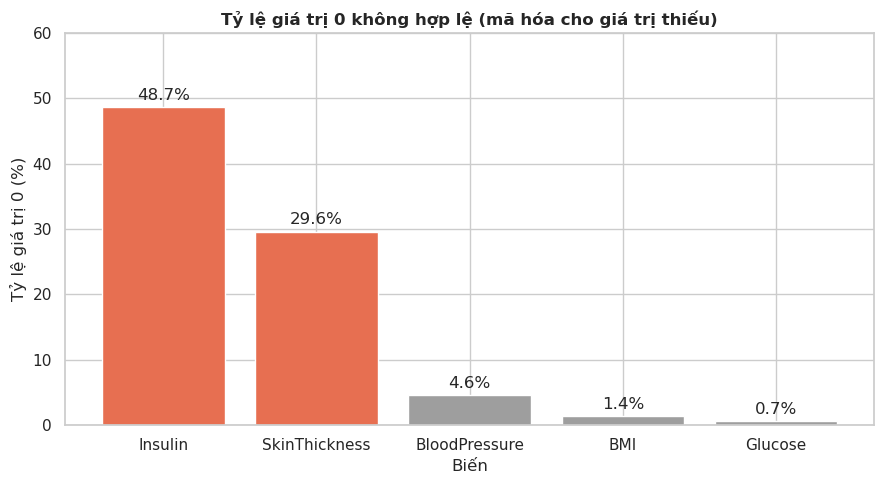

In [34]:
# Biểu đồ cột: tỷ lệ giá trị 0 không hợp lệ theo từng cột
zero_pct = zero_table["Tỷ lệ (%)"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLOR_YES if v > 20 else "#9e9e9e" for v in zero_pct.values]   # tô nổi cột > 20%
bars = ax.bar(zero_pct.index, zero_pct.values, color=bar_colors)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Tỷ lệ giá trị 0 không hợp lệ (mã hóa cho giá trị thiếu)")
ax.set_xlabel("Biến")
ax.set_ylabel("Tỷ lệ giá trị 0 (%)")
ax.set_ylim(0, 60)
plt.tight_layout()
save_fig("hinh_01_ty_le_gia_tri_0")
plt.show()

**Nhận xét:** Insulin có **374/768 giá trị 0 (48,7%)** và SkinThickness có **227 (29,6%)** — gần một nửa và gần một phần ba dữ liệu bị thiếu. Ba cột còn lại thiếu ít: BloodPressure 35 (4,6%), BMI 11 (1,4%), Glucose 5 (0,7%).

### 2.2. Thay giá trị 0 bằng median theo từng nhóm Outcome (theo đúng yêu cầu đề)

Các bước:
1. Đổi 0 → `NaN` để pandas hiểu đó là giá trị thiếu.
2. Với mỗi cột, tính **median riêng cho nhóm Outcome = 0 và nhóm Outcome = 1**, rồi điền vào ô thiếu thuộc nhóm tương ứng (`groupby(...).transform('median')`).

**Vì sao dùng median, không dùng mean?** Median không bị kéo lệch bởi giá trị ngoại lai (Insulin có giá trị tới 846).
**Vì sao theo nhóm Outcome?** Glucose/BMI của nhóm mắc bệnh cao hơn rõ rệt; dùng median chung sẽ kéo hai nhóm lại gần nhau, làm mờ khác biệt khi phân tích.



In [35]:
# Bước 1: đổi 0 -> NaN (bản này giữ lại để dùng cho mô hình ở YC5)
df_nan = df_raw.copy()
df_nan[zero_cols] = df_nan[zero_cols].replace(0, np.nan)

# Median của từng cột theo nhóm Outcome (bỏ qua NaN)
group_median = df_nan.groupby("Outcome")[zero_cols].median()
print("Median theo nhóm Outcome dùng để điền:")
display(group_median)

# Bước 2: điền NaN bằng median của đúng nhóm Outcome
df_clean = df_nan.copy()
for col in zero_cols:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby("Outcome")[col].transform("median"))

print("Số giá trị thiếu còn lại sau khi điền:", df_clean[zero_cols].isnull().sum().sum())
print("Giá trị nhỏ nhất sau làm sạch:")
print(df_clean[zero_cols].min())

Median theo nhóm Outcome dùng để điền:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
Outcome,,,,,
0,107.000,70.000,27.000,102.500,30.100
1,140.000,74.500,32.000,169.500,34.300


Số giá trị thiếu còn lại sau khi điền: 0
Giá trị nhỏ nhất sau làm sạch:
Glucose         44.000
BloodPressure   24.000
SkinThickness    7.000
Insulin         14.000
BMI             18.200
dtype: float64


### 2.3. Kiểm tra dữ liệu trùng lặp

In [36]:
num_duplicates = df_raw.duplicated().sum()
print("Số dòng trùng lặp hoàn toàn:", num_duplicates)
if num_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
print("Kích thước dữ liệu sau làm sạch:", df_clean.shape)

Số dòng trùng lặp hoàn toàn: 0
Kích thước dữ liệu sau làm sạch: (768, 9)


**Nhận xét Yêu cầu 2**

- Sau khi điền, không còn giá trị 0/NaN ở 5 cột; min mới hợp lý về sinh học (Glucose 44, BloodPressure 24, BMI 18,2).
- Median điền cho nhóm mắc bệnh luôn cao hơn nhóm không mắc: Glucose **140 vs 107**, BMI **34,3 vs 30,1**, Insulin **169,5 vs 102,5**.
- **Không có dòng trùng lặp** → giữ nguyên 768 dòng.
- `df_clean` dùng cho EDA và trực quan hóa; `df_nan` (0 → NaN, chưa điền) giữ lại cho mô hình.

## 3. Yêu cầu 3 — Phân tích dữ liệu thăm dò (EDA)

### 3.1. Thống kê mô tả Glucose, BMI, Age, Insulin (sau làm sạch)

In [37]:
df_clean[["Glucose", "BMI", "Age", "Insulin"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,768.000,121.677,30.464,44.000,99.750,117.000,140.250,199.000
BMI,768.000,32.435,6.880,18.200,27.500,32.050,36.600,67.100
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Insulin,768.000,141.754,89.101,14.000,102.500,102.500,169.500,846.000


**Nhận xét:**
- **Glucose** trung bình 121,7 mg/dL, trung vị 117; 25% bệnh nhân có Glucose ≥ 140,25 — mức mà theo ADA (xét nghiệm dung nạp glucose 2 giờ) đã thuộc vùng tiền đái tháo đường (140–199 mg/dL).
- **BMI** trung bình 32,4, trung vị 32,05 → hơn một nửa mẫu có BMI ≥ 30 (béo phì theo WHO).
- **Age** lệch phải: trung vị 29 tuổi nhưng max 81 → mẫu chủ yếu là phụ nữ trẻ.
- **Insulin** trung vị 102,5 và Q1 cũng là 102,5: gần nửa cột là giá trị điền (48,7%) nên phân phối bị "dồn cục" tại giá trị median — dấu hiệu biến này kém tin cậy.

### 3.2. Tỷ lệ mắc bệnh trong toàn mẫu — dữ liệu có mất cân bằng không?

In [38]:
outcome_counts = df_clean["Outcome"].value_counts().sort_index()
outcome_table = pd.DataFrame({
    "Số bệnh nhân": outcome_counts,
    "Tỷ lệ (%)": (outcome_counts / len(df_clean) * 100).round(1),
}).rename(index=OUTCOME_LABELS)
outcome_table

,Số bệnh nhân,Tỷ lệ (%)
Outcome,,
Không mắc (0),500,65.100
Mắc bệnh (1),268,34.900


**Nhận xét:** 500 người không mắc (65,1%) và 268 người mắc (34,9%), tỷ lệ khoảng **1,87 : 1**.
→ Đây là dữ liệu **mất cân bằng ở mức nhẹ** (không nghiêm trọng như Case Study 1, nơi đột quỵ chỉ ~5%). Tuy vậy, một mô hình "đoán tất cả là không mắc" vẫn đạt Accuracy 65%, nên khi đánh giá cần xem thêm **Recall/F1** và chia train/test có `stratify`.

### 3.3. So sánh Glucose, BMI trung bình giữa nhóm mắc / không mắc

In [39]:
compare = df_clean.groupby("Outcome")[["Glucose", "BMI"]].agg(["mean", "median"]).round(2)
compare.index = compare.index.map(OUTCOME_LABELS)
display(compare)

mean_by_group = df_clean.groupby("Outcome")[["Glucose", "BMI"]].mean()
diff = mean_by_group.loc[1] - mean_by_group.loc[0]
pct = diff / mean_by_group.loc[0] * 100
print("Chênh lệch trung bình (Mắc - Không mắc):")
for col in ["Glucose", "BMI"]:
    print(f"  {col}: +{diff[col]:.2f} (cao hơn {pct[col]:.1f}%)")

Glucose            BMI       
                 mean  median   mean median
Outcome                                    
Không mắc (0) 110.620 107.000 30.850 30.100
Mắc bệnh (1)  142.300 140.000 35.400 34.300

Chênh lệch trung bình (Mắc - Không mắc):
  Glucose: +31.68 (cao hơn 28.6%)
  BMI: +4.55 (cao hơn 14.8%)


**Nhận xét:**
- Glucose trung bình nhóm mắc bệnh **142,3** so với **110,6** ở nhóm không mắc — cao hơn **31,7 mg/dL (~28,6%)**.
- BMI trung bình nhóm mắc **35,4** so với **30,85** — cao hơn **4,55 (~14,8%)**.
- Glucose có khác biệt tương đối lớn nhất → dự kiến là chỉ số mạnh nhất, sẽ kiểm chứng bằng biểu đồ và mô hình.

## 4. Yêu cầu 4 — Trực quan hóa dữ liệu (đủ 7 loại biểu đồ)

| # | Loại biểu đồ | Nhóm mục đích | Biến |
|---|---|---|---|
| 4.1 | Cột (Bar) | Số lượng | Pregnancies theo khoảng |
| 4.2 | Đường (Line) | Xu hướng | Glucose TB theo AgeGroup |
| 4.3 | Tròn (Pie) | Tỷ lệ | Outcome |
| 4.4 | Histogram | Phân phối | Glucose, BMI trước/sau xử lý 0 |
| 4.5 | Hộp (Box plot dạng Violin) | Phân phối theo nhóm | Glucose, BMI theo Outcome |
| 4.6 | Phân tán (Scatter) | Quan hệ x–y | Glucose vs BMI, màu theo Outcome |
| 4.7 | Tương quan (Correlogram) | Quan hệ nhiều biến | 8 biến đầu vào + Outcome |

### 4.1. Biểu đồ cột — Số bệnh nhân theo số lần mang thai (nhóm theo khoảng)

**Vì sao chọn biểu đồ cột?** So sánh **số lượng** giữa các nhóm rời rạc. Các nhóm có thứ tự tự nhiên (0 → ≥10 lần) nên giữ nguyên thứ tự, không sắp xếp theo giá trị.

,So_benh_nhan,Ty_le_mac
PregGroup,,
0,111,34.200
1–2,238,20.200
3–4,143,35.000
5–6,107,34.600
7–9,111,58.600
≥10,58,51.700


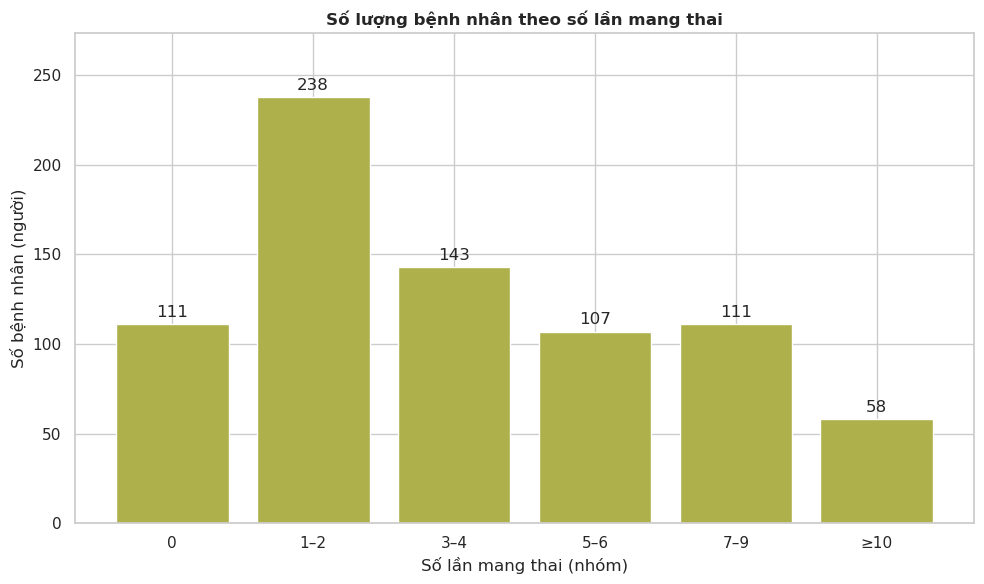

In [40]:
# Chia Pregnancies thành 6 khoảng
preg_bins = [-1, 0, 2, 4, 6, 9, 20]
preg_labels = ["0", "1–2", "3–4", "5–6", "7–9", "≥10"]
df_clean["PregGroup"] = pd.cut(df_clean["Pregnancies"], bins=preg_bins, labels=preg_labels)

preg_summary = df_clean.groupby("PregGroup", observed=True)["Outcome"].agg(
    So_benh_nhan="count", Ty_le_mac=lambda s: round(s.mean() * 100, 1))
display(preg_summary)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(preg_summary.index.astype(str), preg_summary["So_benh_nhan"], color="#aeb04c")
ax.bar_label(bars, padding=3)
ax.set_title("Số lượng bệnh nhân theo số lần mang thai")
ax.set_xlabel("Số lần mang thai (nhóm)")
ax.set_ylabel("Số bệnh nhân (người)")
ax.set_ylim(0, preg_summary["So_benh_nhan"].max() * 1.15)
plt.tight_layout()
save_fig("hinh_02_cot_pregnancies")
plt.show()

**Nhận xét:**
- Nhóm đông nhất là **1–2 lần mang thai (238 người, 31%)**; nhóm ít nhất là **≥10 lần (58 người)**. Số bệnh nhân giảm dần khi số lần mang thai tăng (trừ nhóm 0 lần: 111 người).
- Bảng kèm theo cho thấy **tỷ lệ mắc bệnh tăng theo số lần mang thai**: thấp nhất ở nhóm 1–2 lần (**20,2%**), vọt lên **58,6%** ở nhóm 7–9 lần và **51,7%** ở nhóm ≥10 lần — gần gấp 3 lần nhóm 1–2.
- Lưu ý: Pregnancies tương quan khá mạnh với Age (r = 0,54, xem 4.7), nên một phần tác động này là do tuổi.

### 4.2. Biểu đồ đường — Glucose trung bình theo nhóm tuổi

**Vì sao chọn biểu đồ đường?** Thể hiện **xu hướng** của một biến liên tục (Glucose) theo một biến có thứ tự (nhóm tuổi). Vẽ thêm 2 đường theo Outcome để xem xu hướng có giữ nguyên trong từng nhóm không.

,count,mean,Không mắc (0),Mắc bệnh (1)
AgeGroup,,,,
21–29,396,114.600,107.500,140.600
30–39,165,126.200,113.300,141.200
40–49,118,125.800,109.500,139.100
50–59,57,140.300,123.800,151.400
≥60,32,138.200,131.400,155.800


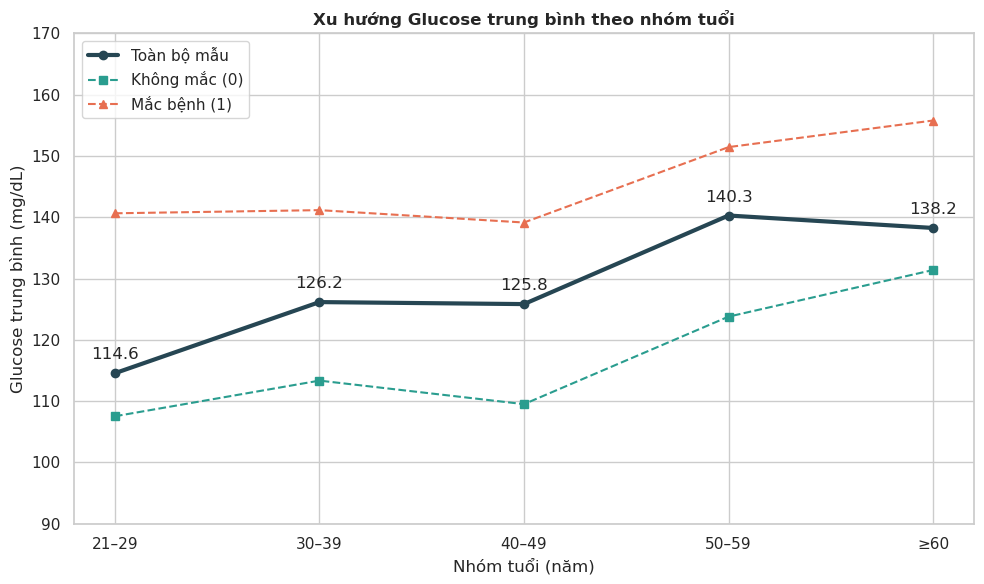

In [41]:
# Chia tuổi thành 5 nhóm
age_bins = [20, 29, 39, 49, 59, 100]
age_labels = ["21–29", "30–39", "40–49", "50–59", "≥60"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=age_bins, labels=age_labels)

glucose_all = df_clean.groupby("AgeGroup", observed=True)["Glucose"].agg(["count", "mean"])
glucose_by_outcome = df_clean.groupby(["AgeGroup", "Outcome"], observed=True)["Glucose"].mean().unstack()
display(pd.concat([glucose_all, glucose_by_outcome.rename(columns=OUTCOME_LABELS)], axis=1).round(1))

fig, ax = plt.subplots(figsize=(10, 6))
x = glucose_all.index.astype(str)
ax.plot(x, glucose_all["mean"], marker="o", linewidth=3, color="#264653", label="Toàn bộ mẫu")
ax.plot(x, glucose_by_outcome[0], marker="s", linestyle="--", color=COLOR_NO, label=OUTCOME_LABELS[0])
ax.plot(x, glucose_by_outcome[1], marker="^", linestyle="--", color=COLOR_YES, label=OUTCOME_LABELS[1])
# Ghi giá trị trên đường "Toàn bộ mẫu"
for xi, yi in zip(x, glucose_all["mean"]):
    ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_title("Xu hướng Glucose trung bình theo nhóm tuổi")
ax.set_xlabel("Nhóm tuổi (năm)")
ax.set_ylabel("Glucose trung bình (mg/dL)")
ax.set_ylim(90, 170)
ax.legend(loc="upper left")
plt.tight_layout()
save_fig("hinh_03_duong_glucose_theo_tuoi")
plt.show()

**Nhận xét:**
- Glucose trung bình **tăng theo tuổi**: từ **114,6 mg/dL** (21–29 tuổi) lên **140,3** (50–59 tuổi), tức tăng ~26 mg/dL; nhóm ≥60 tuổi (138,2) giữ ở mức cao.
- Nhóm 30–39 và 40–49 gần như đi ngang (126,2 và 125,8).
- Trong **mọi** nhóm tuổi, đường "Mắc bệnh" luôn cao hơn đường "Không mắc" khoảng **24–33 mg/dL** → Glucose phân biệt hai nhóm ổn định, không phụ thuộc tuổi.
- Nhóm 50–59 (57 người) và ≥60 (32 người) có ít người nên giá trị trung bình dao động nhiều hơn.

### 4.3. Biểu đồ tròn — Tỷ lệ mắc / không mắc đái tháo đường

**Vì sao chọn biểu đồ tròn?** Thể hiện **tỷ trọng** các phần trong tổng thể; chỉ có 2 phần nên biểu đồ tròn dễ đọc.

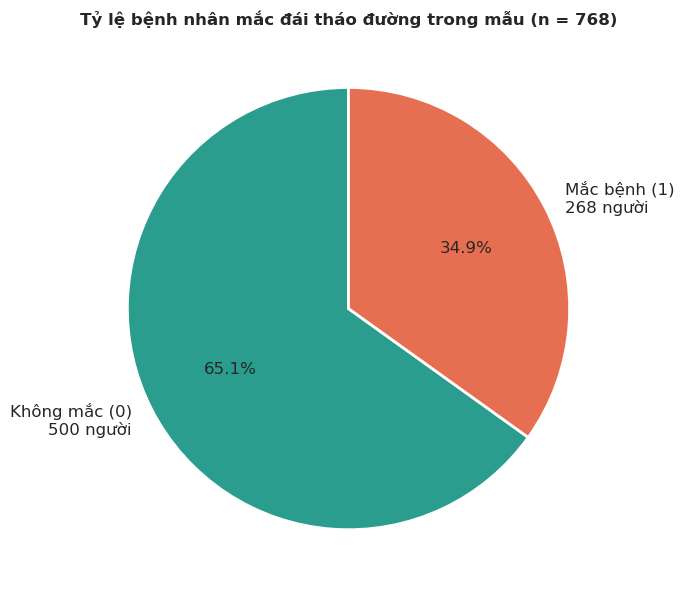

In [42]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(outcome_counts.values,
       labels=[f"{OUTCOME_LABELS[i]}\n{outcome_counts[i]} người" for i in outcome_counts.index],
       colors=[COLOR_NO, COLOR_YES], autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12})
ax.set_title("Tỷ lệ bệnh nhân mắc đái tháo đường trong mẫu (n = 768)")
plt.tight_layout()
save_fig("hinh_04_tron_outcome")
plt.show()

**Nhận xét:**
- Khoảng **1/3 mẫu (34,9%, 268 người)** mắc đái tháo đường; **65,1% (500 người)** không mắc.
- Tỷ lệ mắc trong mẫu rất cao so với cộng đồng nói chung, vì đây là mẫu từ quần thể Pima có nguy cơ cao — kết quả phân tích nên áp dụng thận trọng cho quần thể khác.
- Chênh lệch 2 lớp ở mức nhẹ → vẫn cần `stratify` khi chia dữ liệu và ưu tiên Recall/F1 khi đánh giá.

### 4.4. Histogram — Phân phối Glucose và BMI trước / sau khi xử lý giá trị 0

**Vì sao chọn histogram?** Thể hiện **hình dạng phân phối** của biến liên tục. Đặt trước/sau cạnh nhau để thấy tác động của bước làm sạch.

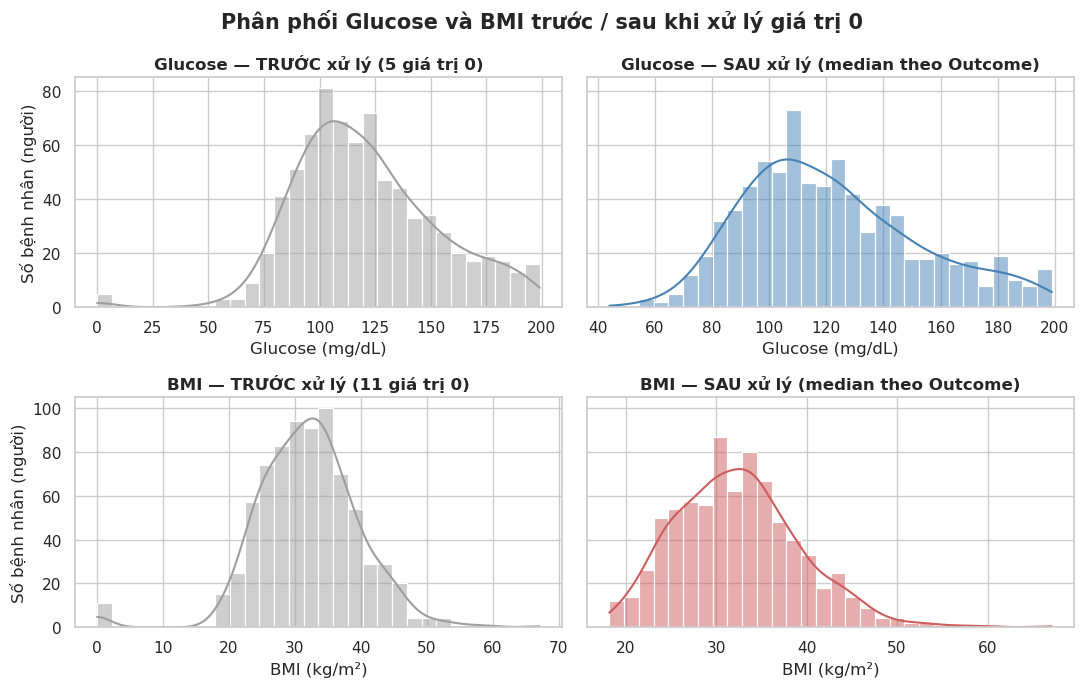

Glucose: TRƯỚC  mean=120.89, min=0 | SAU  mean=121.68, min=44.0
BMI: TRƯỚC  mean=31.99, min=0.0 | SAU  mean=32.43, min=18.2


In [43]:
# sharex="row": 2 hình TRƯỚC/SAU cùng hàng dùng chung thang trục X để so sánh trực tiếp
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex="row", sharey="row")
plot_specs = [
    ("Glucose", "Glucose (mg/dL)", "steelblue"),
    ("BMI", "BMI (kg/m²)", "indianred"),
]
for row, (col, xlabel, color) in enumerate(plot_specs):
    # Cột trái: dữ liệu gốc (còn giá trị 0)
    sns.histplot(df_raw[col], bins=30, kde=True, color="#9e9e9e", ax=axes[row, 0])
    n_zero = (df_raw[col] == 0).sum()
    axes[row, 0].set_title(f"{col} — TRƯỚC xử lý ({n_zero} giá trị 0)")
    axes[row, 0].set_xlabel(xlabel)
    axes[row, 0].set_ylabel("Số bệnh nhân (người)")
    # Cột phải: sau khi thay 0 bằng median theo nhóm Outcome
    sns.histplot(df_clean[col], bins=30, kde=True, color=color, ax=axes[row, 1])
    axes[row, 1].set_title(f"{col} — SAU xử lý (median theo Outcome)")
    axes[row, 1].set_xlabel(xlabel)
    # Ẩn số 0 của trục Y để góc dưới-trái chỉ còn một số 0 (của trục X)
    axes[row, 0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda value, pos: "" if value == 0 else f"{value:g}"))
fig.suptitle("Phân phối Glucose và BMI trước / sau khi xử lý giá trị 0", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig("hinh_05_histogram_truoc_sau")
plt.show()

for col in ["Glucose", "BMI"]:
    print(f"{col}: TRƯỚC  mean={df_raw[col].mean():.2f}, min={df_raw[col].min()} | "
          f"SAU  mean={df_clean[col].mean():.2f}, min={df_clean[col].min()}")

**Nhận xét:**
- **Trước xử lý**, cả hai histogram có một cột tách biệt ở giá trị 0 (Glucose 5 dòng, BMI 11 dòng) nằm rất xa phần còn lại → kéo dài trục x và làm sai lệch thống kê (min = 0).
- **Sau xử lý**, cột 0 biến mất; trục x co về vùng hợp lý (Glucose 44–199, BMI 18,2–67,1). Trung bình tăng nhẹ: Glucose 120,89 → 121,68; BMI 31,99 → 32,43.
- **Glucose** có dạng gần chuẩn, hơi lệch phải, đỉnh khoảng 100–110 mg/dL. **BMI** lệch phải nhẹ, đỉnh khoảng 30–33, có vài giá trị rất cao (> 50).
- Vì Glucose và BMI chỉ thiếu ít (< 1,5%) nên điền median không làm méo phân phối. Với Insulin (48,7% thiếu), điền median sẽ tạo một "cột cao bất thường" tại giá trị median — lý do để cân nhắc loại Insulin khỏi mô hình.

### 4.5. Biểu đồ hộp (dạng Violin + Box) — Glucose và BMI theo Outcome

**Vì sao chọn box plot?** So sánh **phân phối** (trung vị, tứ phân vị, outlier) giữa hai nhóm cùng lúc; bổ trợ cho histogram. Ở đây vẽ dưới dạng **violin có lồng box plot bên trong** (`inner="box"`): phần "thân" violin cho người xem thấy ngay *hình dạng mật độ dữ liệu* mà không cần hiểu trước thuật ngữ tứ phân vị, trong khi hộp nhỏ bên trong vẫn giữ nguyên đầy đủ thông tin của box plot truyền thống (trung vị, Q1–Q3).

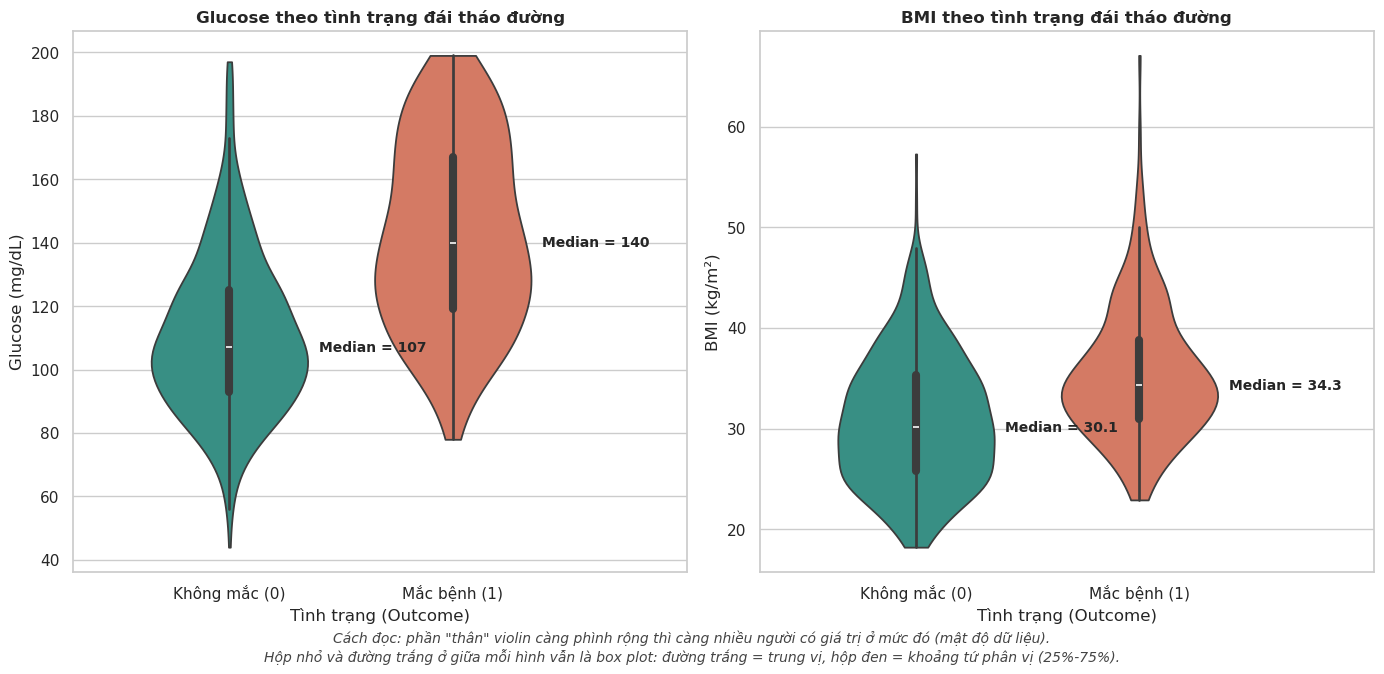

Glucose                    BMI              
                0.250   0.500   0.750  0.250  0.500  0.750
Outcome                                                   
Không mắc (0)  93.000 107.000 125.000 25.750 30.100 35.300
Mắc bệnh (1)  119.000 140.000 167.000 30.900 34.300 38.775

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
box_specs = [("Glucose", "Glucose (mg/dL)"), ("BMI", "BMI (kg/m²)")]
for ax, (col, ylabel) in zip(axes, box_specs):
    sns.violinplot(x="Outcome", y=col, data=df_clean, hue="Outcome",
                   palette=OUTCOME_PALETTE, legend=False, ax=ax,
                   width=0.7, inner="box", cut=0, linewidth=1.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([OUTCOME_LABELS[0], OUTCOME_LABELS[1]])
    ax.set_title(f"{col} theo tình trạng đái tháo đường")
    ax.set_xlabel("Tình trạng (Outcome)")
    ax.set_ylabel(ylabel)
    # Ghi giá trị trung vị lên từng hình (hộp nhỏ bên trong violin đã có sẵn đường trung vị)
    medians = df_clean.groupby("Outcome")[col].median()
    for i, m in enumerate(medians):
        ax.text(i + 0.4, m, f"Median = {m:g}", va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(-0.7, 2.05)   # chừa chỗ bên phải cho nhãn median

# Chú thích cách đọc violin + box ngay trên hình, để người nghe không cần biết trước thuật ngữ
fig.text(0.5, -0.03,
         "Cách đọc: phần \"thân\" violin càng phình rộng thì càng nhiều người có giá trị ở mức đó (mật độ dữ liệu).\n"
         "Hộp nhỏ và đường trắng ở giữa mỗi hình vẫn là box plot: đường trắng = trung vị, hộp đen = khoảng tứ phân vị (25%-75%).",
         ha="center", fontsize=10, style="italic", color="#444444")

plt.tight_layout()
save_fig("hinh_06_violin_glucose_bmi")
plt.show()

# Bảng tứ phân vị để trích số liệu
quartiles = df_clean.groupby("Outcome")[["Glucose", "BMI"]].quantile([0.25, 0.5, 0.75]).unstack()
quartiles.index = quartiles.index.map(OUTCOME_LABELS)
quartiles

**Nhận xét:**
- **Glucose:** trung vị nhóm mắc **140** so với **107** ở nhóm không mắc. Ngay cả Q1 của nhóm mắc (**119**) cũng cao hơn trung vị nhóm không mắc (107), tức **75% người mắc có Glucose ≥ 119**; Q3 hai nhóm là 167 và 125 → Glucose tách hai nhóm rất rõ.
- **BMI:** trung vị **34,3 vs 30,1**; hai hộp vẫn chồng lấn đáng kể (Q1 nhóm mắc 30,9 < Q3 nhóm không mắc 35,3) → BMI phân biệt kém hơn Glucose.
- Outlier (quy tắc 1,5×IQR): nhóm không mắc có **11 điểm Glucose ngoại lai** (10 ca > 173 mg/dL — có thể là người có đường huyết cao nhưng chưa được chẩn đoán); BMI có **8 ca > 50** (2 không mắc, 6 mắc). Các giá trị này vẫn hợp lý về sinh học nên giữ lại, không xóa.
- Hình dạng "thân" violin cho thấy thêm điều box plot thường không thể hiện: phân phối Glucose ở nhóm mắc bệnh khá dàn trải (thân rộng đều từ ~120–170), trong khi nhóm không mắc tập trung dày ở khoảng 90–110 (thân phình mạnh một chỗ) — tức người không mắc bệnh có mức đường huyết đồng đều hơn hẳn.

### 4.6. Biểu đồ phân tán — Glucose vs BMI, màu theo Outcome

**Vì sao chọn scatter?** Xem **quan hệ giữa hai biến định lượng** và cách hai nhóm Outcome phân bố trên mặt phẳng. Thêm hai đường tham chiếu lâm sàng: Glucose = 140 mg/dL (ngưỡng tiền đái tháo đường của nghiệm pháp 2 giờ, ADA) và BMI = 30 (ngưỡng béo phì, WHO).

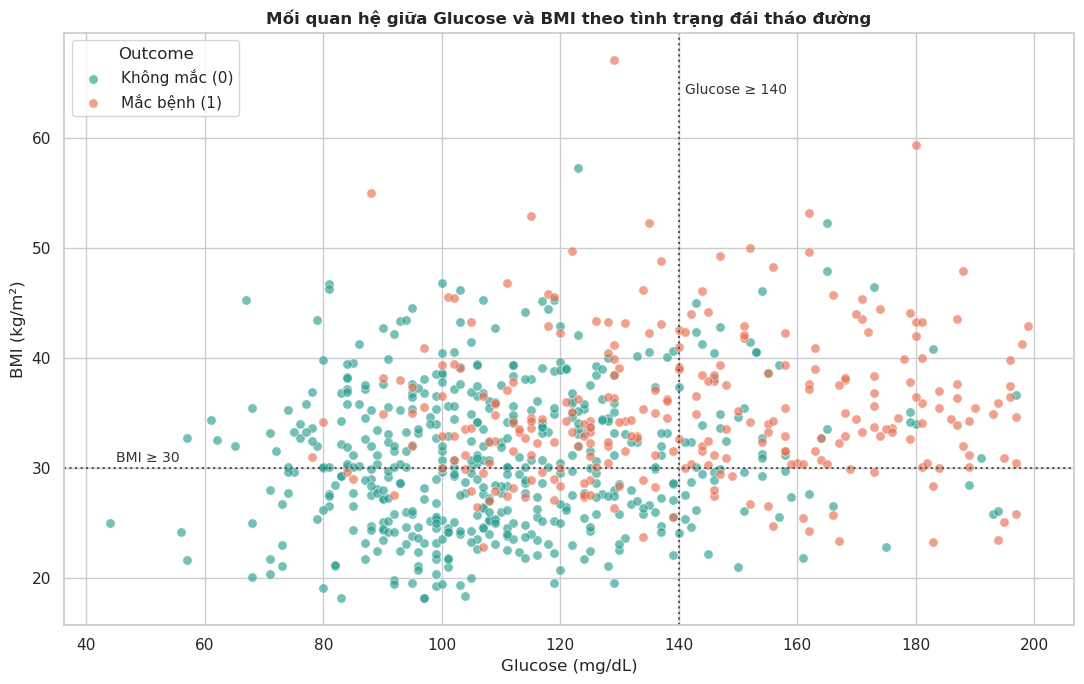

Glucose–BMI tương quan r = 0.24


So_benh_nhan  Ty_le_mac
Glucose < 140 BMI < 30           242     12.000
              BMI ≥ 30           327     31.200
Glucose ≥ 140 BMI < 30            43     41.900
              BMI ≥ 30           156     76.300

In [45]:
fig, ax = plt.subplots(figsize=(11, 7))
for outcome, color in OUTCOME_PALETTE.items():
    subset = df_clean[df_clean["Outcome"] == outcome]
    ax.scatter(subset["Glucose"], subset["BMI"], c=color, alpha=0.65,
               edgecolor="white", linewidth=0.5, s=45, label=OUTCOME_LABELS[outcome])
ax.axvline(140, color="#555555", linestyle=":", linewidth=1.5)
ax.axhline(30, color="#555555", linestyle=":", linewidth=1.5)
ax.text(141, 64, "Glucose ≥ 140", fontsize=10, color="#333333")
ax.text(45, 30.6, "BMI ≥ 30", fontsize=10, color="#333333")
ax.set_title("Mối quan hệ giữa Glucose và BMI theo tình trạng đái tháo đường")
ax.set_xlabel("Glucose (mg/dL)")
ax.set_ylabel("BMI (kg/m²)")
ax.legend(title="Outcome", loc="upper left")
plt.tight_layout()
save_fig("hinh_07_scatter_glucose_bmi")
plt.show()

# Tỷ lệ mắc bệnh trong 4 vùng chia bởi 2 đường tham chiếu
high_glucose = np.where(df_clean["Glucose"] >= 140, "Glucose ≥ 140", "Glucose < 140")
high_bmi = np.where(df_clean["BMI"] >= 30, "BMI ≥ 30", "BMI < 30")
quadrant = df_clean.groupby([high_glucose, high_bmi])["Outcome"].agg(
    So_benh_nhan="count", Ty_le_mac=lambda s: round(s.mean() * 100, 1))
print("Glucose–BMI tương quan r =", round(df_clean["Glucose"].corr(df_clean["BMI"]), 2))
quadrant

**Nhận xét:**
- Glucose và BMI chỉ tương quan yếu với nhau (**r ≈ 0,24**) → hai chỉ số mang thông tin **bổ sung** cho nhau, nên dùng kết hợp.
- Các điểm cam (mắc bệnh) tập trung ở **góc trên bên phải** (Glucose ≥ 140 và BMI ≥ 30). Tỷ lệ mắc trong vùng này là **76,3% (156 người)**, gấp khoảng **6 lần** vùng Glucose < 140 và BMI < 30 (**12,0%**, 242 người).
- Hai vùng trung gian: Glucose cao nhưng BMI < 30 → **41,9%**; BMI cao nhưng Glucose < 140 → **31,2%**. Glucose cao "nguy hiểm" hơn BMI cao.
- Kết hợp với box plot: nhóm nguy cơ cao nhất là phụ nữ **vừa có Glucose ≥ 140 vừa béo phì**.

### 4.7. Biểu đồ tương quan (Correlogram) — 8 biến đầu vào + Outcome

**Vì sao chọn heatmap tương quan?** Xem **cùng lúc** hệ số tương quan Pearson giữa mọi cặp biến; bảng màu phân kỳ `coolwarm`, cố định thang −1 đến +1.

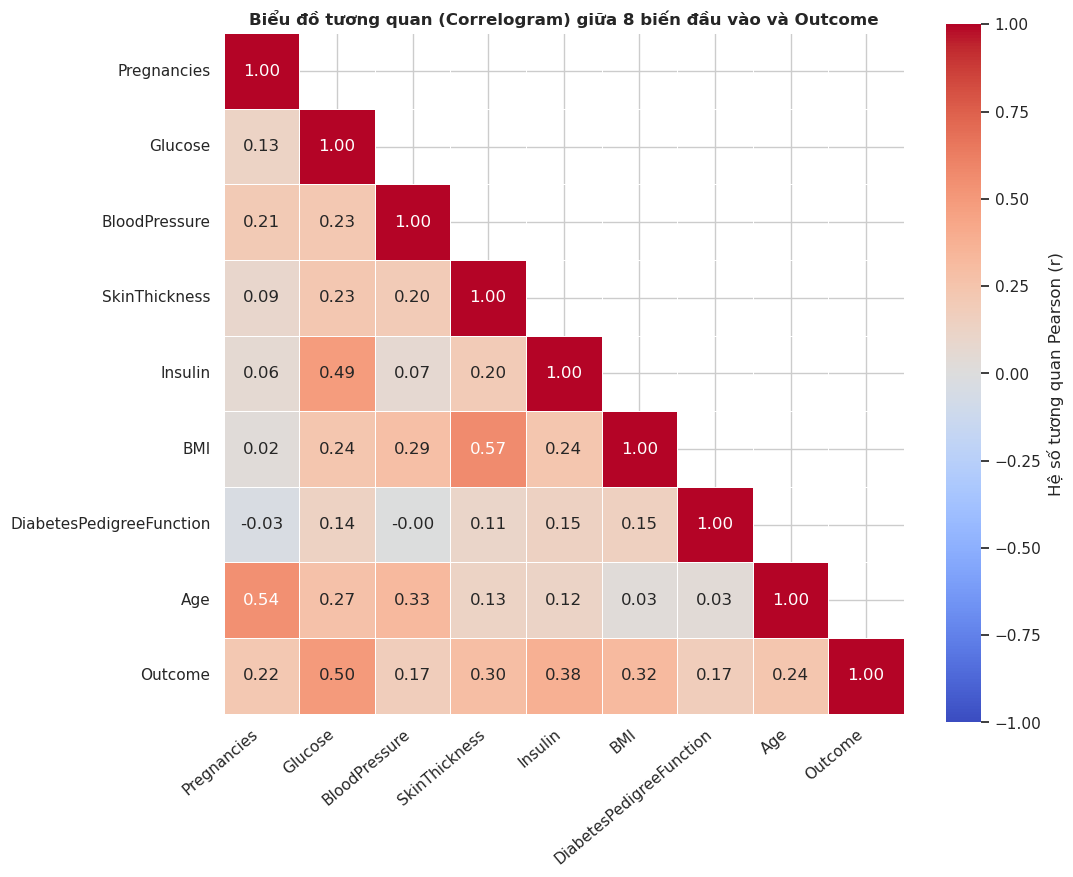

,r (sau điền median theo nhóm),"r (chưa điền, bỏ NaN)"
Glucose,0.496,0.495
Insulin,0.377,0.303
BMI,0.316,0.314
SkinThickness,0.295,0.259
Age,0.238,0.238
Pregnancies,0.222,0.222
BloodPressure,0.174,0.171
DiabetesPedigreeFunction,0.174,0.174


In [46]:
corr_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
             "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
corr_matrix = df_clean[corr_cols].corr()

# Chỉ vẽ nửa dưới để đỡ lặp thông tin
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "Hệ số tương quan Pearson (r)"}, ax=ax)
ax.set_title("Biểu đồ tương quan (Correlogram) giữa 8 biến đầu vào và Outcome")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
save_fig("hinh_08_correlogram")
plt.show()

# Xếp hạng tương quan với Outcome
corr_outcome = corr_matrix["Outcome"].drop("Outcome").sort_values(ascending=False)
# So sánh với tương quan tính trên dữ liệu chưa điền (0 -> NaN, pandas tự bỏ NaN)
corr_outcome_nan = df_nan[corr_cols].corr()["Outcome"].drop("Outcome")
pd.DataFrame({"r (sau điền median theo nhóm)": corr_outcome,
              "r (chưa điền, bỏ NaN)": corr_outcome_nan[corr_outcome.index]}).round(3)

**Nhận xét:**
- Biến tương quan mạnh nhất với Outcome là **Glucose (r = 0,496)**, tiếp theo là Insulin (0,377), BMI (0,316), SkinThickness (0,295), Age (0,238), Pregnancies (0,222).
- **Cảnh báo:** tương quan của **Insulin (0,377) và SkinThickness (0,295) bị thổi phồng** do điền median theo nhóm Outcome — trên dữ liệu chưa điền chỉ còn 0,303 và 0,259. Insulin có 48,7% giá trị là "median của nhóm" nên gần như mang sẵn thông tin nhãn. Glucose, BMI, Age hầu như không đổi (thiếu ít hoặc không thiếu).
- **DiabetesPedigreeFunction** (yếu tố di truyền) chỉ tương quan **yếu (r = 0,174)** với Outcome — có liên hệ nhưng không đáng kể bằng Glucose/BMI.
- Các cặp biến đầu vào tương quan với nhau: **SkinThickness–BMI (0,57)**, **Pregnancies–Age (0,54)**, **Glucose–Insulin (0,49)** → Insulin và SkinThickness phần lớn trùng thông tin với Glucose và BMI.

## 5. Yêu cầu 5 — Mô hình Hồi quy Logistic dự đoán Outcome

### 5.1. Lựa chọn biến và cách xử lý giá trị thiếu

**Loại Insulin khỏi mô hình** vì:
1. Thiếu **48,7%** — điền giá trị cho gần nửa cột là "tự tạo ra" dữ liệu.
2. Insulin tương quan 0,49 với Glucose → thông tin chính đã có trong Glucose.
3. Tình huống yêu cầu công cụ sàng lọc **không cần xét nghiệm chuyên sâu**; insulin huyết thanh là xét nghiệm tốn kém hơn.

(SkinThickness thiếu 29,6% — vẫn giữ theo mức đề yêu cầu tối thiểu, kết quả hệ số ở 5.4 cho thấy nó gần như không đóng góp.)

**Xử lý giá trị thiếu đúng cách (không data leakage):** dùng `Pipeline` gồm 3 bước chạy nối tiếp:
1. `SimpleImputer(strategy="median")` — điền NaN bằng median **tính trên tập train**, không dùng Outcome.
2. `StandardScaler` — chuẩn hóa về mean 0, độ lệch chuẩn 1 (fit trên train). Nhờ chuẩn hóa, độ lớn của các hệ số hồi quy **so sánh được với nhau**.
3. `LogisticRegression` — mô hình phân loại nhị phân: tính tổ hợp tuyến tính các biến rồi đưa qua hàm sigmoid → xác suất mắc bệnh.

Chia dữ liệu **80% train / 20% test**, `stratify=y` để giữ tỷ lệ 35% mắc ở cả hai tập.

In [47]:
feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "BMI", "DiabetesPedigreeFunction", "Age"]   # đã bỏ Insulin

X = df_nan[feature_cols]       # dữ liệu 0 -> NaN, CHƯA điền
y = df_nan["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "- tỷ lệ mắc:", round(y_train.mean() * 100, 1), "%")
print("Test :", X_test.shape, "- tỷ lệ mắc:", round(y_test.mean() * 100, 1), "%")

model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)),
])
model_pipeline.fit(X_train, y_train)
print("Đã huấn luyện xong mô hình.")

Train: (614, 7) - tỷ lệ mắc: 34.9 %
Test : (154, 7) - tỷ lệ mắc: 35.1 %
Đã huấn luyện xong mô hình.


### 5.2. Đánh giá trên tập test (ngưỡng mặc định 0,5)

In [48]:
y_prob = model_pipeline.predict_proba(X_test)[:, 1]   # xác suất mắc bệnh
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1-score :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Không mắc", "Mắc bệnh"]))

Accuracy : 0.695
Precision: 0.578
Recall   : 0.481
F1-score : 0.525
ROC-AUC  : 0.812

              precision    recall  f1-score   support

   Không mắc       0.74      0.81      0.78       100
    Mắc bệnh       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



**Giải thích các độ đo** (lớp "Mắc bệnh" là lớp dương):
- **Accuracy** = tỷ lệ dự đoán đúng trên tổng số.
- **Precision** = trong số người mô hình báo "mắc", bao nhiêu % mắc thật.
- **Recall** = trong số người mắc thật, mô hình phát hiện được bao nhiêu % → **quan trọng nhất với sàng lọc**, vì bỏ sót người bệnh (FN) nguy hiểm hơn báo nhầm (FP).
- **F1** = trung bình điều hòa của Precision và Recall.
- **ROC-AUC** = khả năng xếp hạng người mắc có xác suất cao hơn người không mắc (0,5 = đoán ngẫu nhiên, 1 = hoàn hảo).

**Nhận xét:** Accuracy **0,695**, ROC-AUC **0,812** (khả năng phân biệt khá). Nhưng ở ngưỡng 0,5, **Recall chỉ 0,481** — mô hình bỏ sót hơn một nửa số người mắc bệnh. Với công cụ sàng lọc, như vậy là chưa đạt → cần hạ ngưỡng (mục 5.3).

### 5.3. Chọn ngưỡng quyết định cho mục tiêu sàng lọc

Để không "nhìn trộm" tập test, ngưỡng được chọn bằng **cross-validation 5-fold trên tập train**: tính xác suất dự đoán cho từng người trong train (mỗi người được dự đoán bởi mô hình không học người đó), rồi so sánh các ngưỡng.

In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_prob_cv = cross_val_predict(model_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

rows = []
for threshold in [0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    pred = (train_prob_cv >= threshold).astype(int)
    rows.append({"Ngưỡng": threshold,
                 "Accuracy": accuracy_score(y_train, pred),
                 "Precision": precision_score(y_train, pred),
                 "Recall": recall_score(y_train, pred),
                 "F1": f1_score(y_train, pred)})
threshold_table = pd.DataFrame(rows).round(3)
threshold_table

,Ngưỡng,Accuracy,Precision,Recall,F1
0,0.500,0.787,0.755,0.575,0.653
1,0.450,0.785,0.716,0.636,0.673
2,0.400,0.779,0.686,0.673,0.679
3,0.350,0.767,0.652,0.710,0.680
4,0.300,0.741,0.597,0.790,0.680
5,0.250,0.720,0.566,0.836,0.675


**Nhận xét:** Khi hạ ngưỡng từ 0,5 xuống 0,3, Recall (CV trên train) tăng từ **0,575 lên 0,790** trong khi F1 vẫn giữ ~0,68 và Accuracy chỉ giảm từ 0,787 xuống 0,741. Hạ tiếp xuống 0,25 thì Recall tăng thêm ít nhưng F1 bắt đầu giảm. → Chọn **ngưỡng 0,3** cho mục đích sàng lọc.

Áp dụng ngưỡng 0,3 lên tập test:

,"Ngưỡng 0,5","Ngưỡng 0,3 (sàng lọc)"
Accuracy,0.695,0.727
Precision,0.578,0.581
Recall,0.481,0.796
F1-score,0.525,0.672


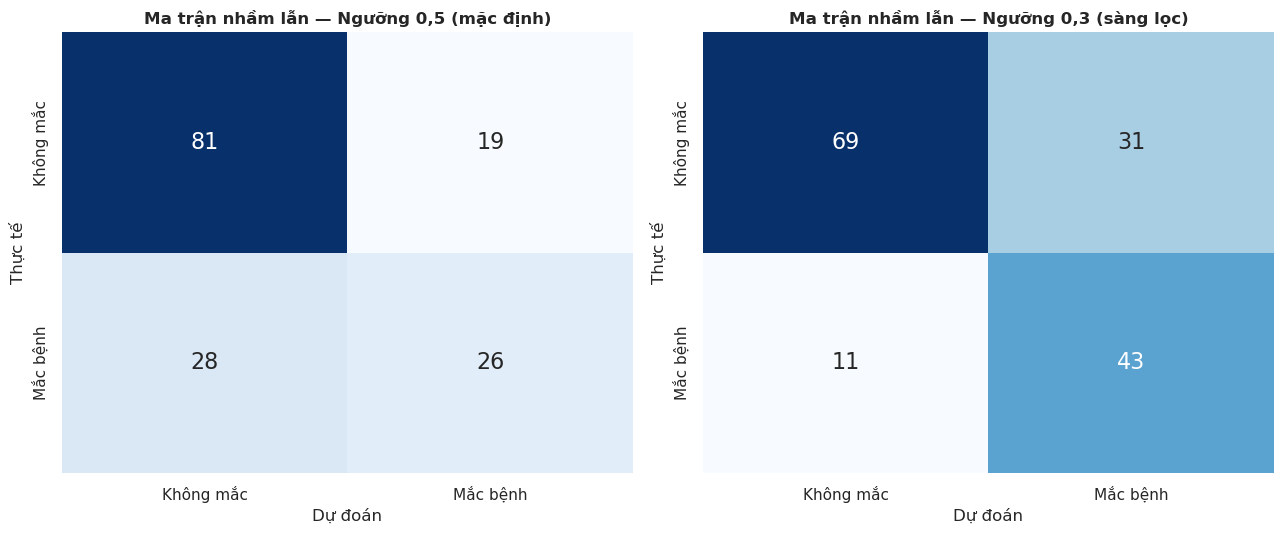

In [50]:
SCREEN_THRESHOLD = 0.3
y_pred_screen = (y_prob >= SCREEN_THRESHOLD).astype(int)

result_compare = pd.DataFrame({
    "Ngưỡng 0,5": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                   recall_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "Ngưỡng 0,3 (sàng lọc)": [accuracy_score(y_test, y_pred_screen), precision_score(y_test, y_pred_screen),
                               recall_score(y_test, y_pred_screen), f1_score(y_test, y_pred_screen)],
}, index=["Accuracy", "Precision", "Recall", "F1-score"]).round(3)
display(result_compare)

# Vẽ 2 ma trận nhầm lẫn cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
tick_labels = ["Không mắc", "Mắc bệnh"]
for ax, pred, title in zip(axes, [y_pred, y_pred_screen],
                           ["Ngưỡng 0,5 (mặc định)", "Ngưỡng 0,3 (sàng lọc)"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16},
                xticklabels=tick_labels, yticklabels=tick_labels, ax=ax)
    ax.set_title(f"Ma trận nhầm lẫn — {title}")
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
plt.tight_layout()
save_fig("hinh_09_confusion_matrix")
plt.show()

**Nhận xét ma trận nhầm lẫn (154 người trong tập test, 54 người mắc):**
- **Ngưỡng 0,5:** TN = 81, FP = 19, **FN = 28**, TP = 26 → bỏ sót 28/54 người bệnh.
- **Ngưỡng 0,3:** TN = 69, FP = 31, **FN = 11**, TP = 43 → Recall tăng từ **0,481 lên 0,796**, số ca bỏ sót giảm từ 28 xuống **11**. Đổi lại có thêm 12 ca báo nhầm (FP 19 → 31), chấp nhận được vì người bị báo nhầm chỉ phải làm thêm xét nghiệm xác nhận.
- Accuracy thậm chí tăng nhẹ (0,695 → 0,727) và F1 tăng (0,525 → 0,672).

### 5.4. Hệ số hồi quy — biến nào ảnh hưởng mạnh nhất?

Vì các biến đã được chuẩn hóa, **|hệ số| lớn hơn = ảnh hưởng mạnh hơn** (khi tăng 1 độ lệch chuẩn). Hệ số dương → làm tăng xác suất mắc bệnh. `exp(hệ số)` = **odds ratio**: số lần odds mắc bệnh nhân lên khi biến tăng 1 độ lệch chuẩn.

,He_so,Odds_ratio
Glucose,1.155,3.172
BMI,0.681,1.976
Pregnancies,0.375,1.455
DiabetesPedigreeFunction,0.228,1.256
Age,0.150,1.162
BloodPressure,-0.041,0.959
SkinThickness,0.025,1.025


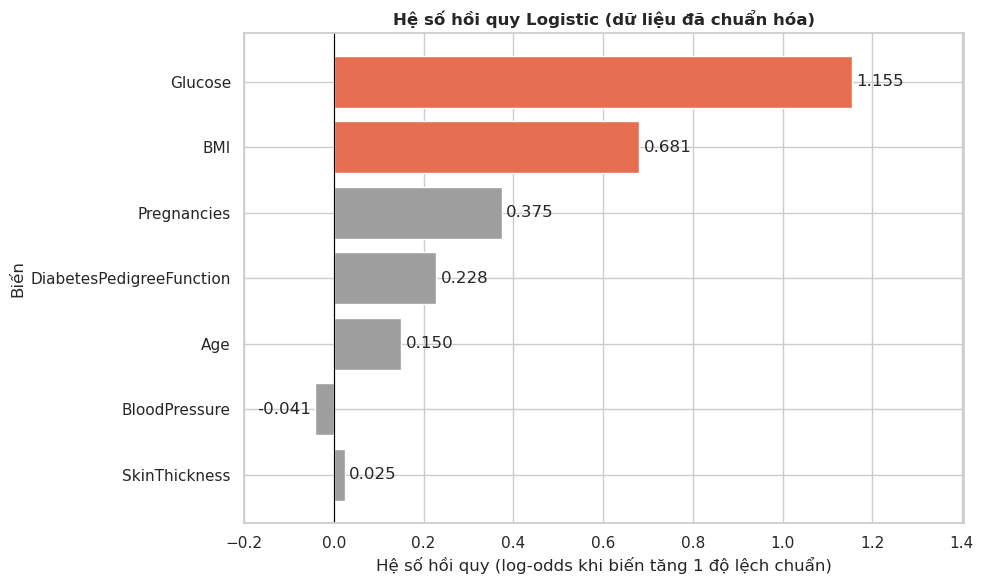

In [51]:
coefs = pd.DataFrame({
    "He_so": model_pipeline.named_steps["model"].coef_[0],
}, index=feature_cols)
coefs["Odds_ratio"] = np.exp(coefs["He_so"])
coefs = coefs.reindex(coefs["He_so"].abs().sort_values(ascending=False).index)
display(coefs.round(3))

# Biểu đồ cột ngang hệ số hồi quy (sắp xếp theo độ lớn)
plot_coefs = coefs["He_so"].iloc[::-1]
colors = [COLOR_YES if name in ["Glucose", "BMI"] else "#9e9e9e" for name in plot_coefs.index]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_coefs.index, plot_coefs.values, color=colors)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Hệ số hồi quy Logistic (dữ liệu đã chuẩn hóa)")
ax.set_xlabel("Hệ số hồi quy (log-odds khi biến tăng 1 độ lệch chuẩn)")
ax.set_ylabel("Biến")
ax.set_xlim(min(plot_coefs.min() - 0.15, -0.2), plot_coefs.max() + 0.25)
plt.tight_layout()
save_fig("hinh_10_he_so_hoi_quy")
plt.show()

**Nhận xét:**
- **Glucose có hệ số lớn nhất (1,155, odds ratio ≈ 3,17)**: Glucose tăng 1 độ lệch chuẩn (~30 mg/dL) thì odds mắc bệnh tăng khoảng **3,2 lần** (khi giữ nguyên các biến khác). Đây là biến ảnh hưởng mạnh nhất.
- Xếp tiếp theo: **BMI (0,681; OR ≈ 1,98)**, Pregnancies (0,375), DiabetesPedigreeFunction (0,228), Age (0,150).
- **BloodPressure (−0,041) và SkinThickness (0,025)** gần như bằng 0 → không đóng góp thêm khi đã có các biến khác (SkinThickness trùng thông tin với BMI, r = 0,57).
- Age có hệ số nhỏ dù tương quan đơn 0,24 vì phần lớn tác động của tuổi đã được Pregnancies "chia sẻ" (r = 0,54 giữa hai biến).

### 5.5. Minh chứng data leakage: nếu dùng dữ liệu điền median theo nhóm Outcome cho mô hình

Thí nghiệm đối chứng: huấn luyện cùng một mô hình (có cả Insulin) trên `df_clean` (điền theo nhóm Outcome — cách của Yêu cầu 2) và trên `df_nan` (điền median train, không dùng Outcome).

In [52]:
def train_and_get_coefs(data, features, use_imputer):
    # Huấn luyện Logistic trên cùng cách chia train/test, trả về (hệ số, AUC test)
    X_ = data[features]
    y_ = data["Outcome"]
    X_tr, X_te, y_tr, y_te = train_test_split(X_, y_, test_size=0.2, random_state=42, stratify=y_)
    steps = [("imputer", SimpleImputer(strategy="median"))] if use_imputer else []
    steps += [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]
    pipe = Pipeline(steps).fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
    return pd.Series(pipe.named_steps["model"].coef_[0], index=features), auc

features_with_insulin = feature_cols + ["Insulin"]
coef_leak, auc_leak = train_and_get_coefs(df_clean, features_with_insulin, use_imputer=False)
coef_ok, auc_ok = train_and_get_coefs(df_nan, features_with_insulin, use_imputer=True)

leak_table = pd.DataFrame({"Điền theo nhóm Outcome (leakage)": coef_leak,
                           "Điền median train (đúng)": coef_ok}).round(3)
display(leak_table.sort_values("Điền theo nhóm Outcome (leakage)", ascending=False))
print(f"ROC-AUC test — leakage: {auc_leak:.3f} | đúng: {auc_ok:.3f}")

,Điền theo nhóm Outcome (leakage),Điền median train (đúng)
Glucose,0.935,1.183
Insulin,0.614,-0.066
BMI,0.466,0.689
Pregnancies,0.337,0.377
SkinThickness,0.295,0.028
DiabetesPedigreeFunction,0.175,0.233
Age,0.160,0.148
BloodPressure,-0.004,-0.044


ROC-AUC test — leakage: 0.826 | đúng: 0.813


**Nhận xét:**
- Khi dùng dữ liệu điền theo nhóm Outcome, **Insulin trở thành biến mạnh thứ 2 (hệ số 0,614)**. Khi điền đúng cách (không dùng nhãn), hệ số Insulin chỉ còn **−0,066** — tức gần như **không có tác dụng**. Tương tự, SkinThickness tụt từ 0,307 xuống 0,028.
- Nguyên nhân: gần 50% giá trị Insulin là "median của nhóm mắc" hoặc "median của nhóm không mắc" → giá trị điền **chứa sẵn đáp án**, mô hình học thuộc đáp án chứ không học quy luật sinh học.
- ROC-AUC cũng bị thổi phồng (0,826 so với 0,813). Với bệnh nhân mới (chưa biết Outcome), mô hình leakage không thể áp dụng được.
- → Khẳng định lựa chọn ở 5.1: **điền median train cho mô hình** và **loại Insulin**.

## 6. Kết luận

### 6.1. Ba chỉ số sinh học liên hệ mạnh nhất với nguy cơ đái tháo đường

| Hạng | Chỉ số | Bằng chứng |
|---|---|---|
| 1 | **Glucose** (nghiệm pháp 2 giờ) | r = 0,50 (cao nhất); hệ số Logistic 1,155 (OR ≈ 3,2); trung vị 140 vs 107 mg/dL |
| 2 | **BMI** | r = 0,32; hệ số 0,681 (OR ≈ 2,0); trung vị 34,3 vs 30,1 |
| 3 | **Tuổi (kèm số lần mang thai)** | Age r = 0,24, Pregnancies r = 0,22 (hai biến tương quan 0,54); Glucose TB tăng 114,6 → 140,3 mg/dL từ nhóm 21–29 đến 50–59 tuổi; tỷ lệ mắc 58,6% ở nhóm mang thai 7–9 lần so với 20,2% ở nhóm 1–2 lần |

- Insulin và SkinThickness trông có vẻ tương quan cao nhưng là do thiếu dữ liệu nặng + điền theo nhóm; khi xử lý đúng thì gần như không đóng góp.
- Yếu tố di truyền (DiabetesPedigreeFunction) có liên hệ nhưng yếu (r = 0,17).
- Kết hợp **Glucose ≥ 140 và BMI ≥ 30** → tỷ lệ mắc **76,3%**, gấp ~6 lần nhóm không có yếu tố nào (12,0%).

### 6.2. Hai đề xuất cho chương trình sàng lọc sớm

1. **Sàng lọc 2 bước dựa trên chỉ số rẻ, sẵn có:** đo đường huyết (Glucose) + BMI cho mọi phụ nữ đến khám định kỳ; ưu tiên chuyển xét nghiệm chẩn đoán cho nhóm **Glucose ≥ 140 mg/dL và BMI ≥ 30**, đặc biệt khi tuổi ≥ 40 hoặc đã mang thai ≥ 7 lần. Không cần đưa Insulin/SkinThickness vào công cụ.
2. **Dùng mô hình Logistic 7 biến với ngưỡng 0,3 thay vì 0,5:** Recall tăng từ 48% lên ~80% (bỏ sót chỉ 11/54 ca trong tập test thay vì 28/54). Người có kết quả dương tính được làm xét nghiệm xác nhận. Đồng thời **chuẩn hóa quy trình ghi nhận dữ liệu** (bỏ trống thay vì ghi 0 khi không đo) để lần cập nhật mô hình sau có dữ liệu chất lượng hơn.

### 6.3. Hạn chế
- Mẫu chỉ gồm phụ nữ Pima ≥ 21 tuổi, 768 người → cần kiểm chứng trên dữ liệu bệnh nhân của phòng khám trước khi áp dụng.
- Tập test chỉ 154 người, các chỉ số có thể dao động theo cách chia dữ liệu.
- Tương quan không hàm ý nhân quả.